# Browse Train First Frames (1044 Camera)

依次浏览 `flip_0326_purple_box/train` 下前 50 个 scene 的第一帧图像。

规则：
- 固定相机：`cam_104422070117`
- 固定读取：`color/` 目录下按文件名排序后的第一张
- 每按一次回车，显示下一张


In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

TRAIN_ROOT = Path('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train')
CAMERA_DIRNAME = 'cam_104422070117'
MAX_SCENES = 50

scene_dirs = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir() and p.name.startswith('scene_')])[:MAX_SCENES]
print(f'found {len(scene_dirs)} scenes under {TRAIN_ROOT}')


found 50 scenes under /data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train


In [2]:
items = []
for scene_dir in scene_dirs:
    color_dir = scene_dir / CAMERA_DIRNAME / 'color'
    if not color_dir.exists():
        items.append((scene_dir.name, None, 'missing color dir'))
        continue
    frames = sorted(color_dir.glob('*.png'))
    if len(frames) == 0:
        items.append((scene_dir.name, None, 'no png found'))
        continue
    items.append((scene_dir.name, frames[0], None))

ok = sum(1 for _, p, e in items if p is not None and e is None)
bad = len(items) - ok
print(f'usable scenes: {ok}, missing scenes: {bad}')
items[:5]


usable scenes: 50, missing scenes: 0


[('scene_0001',
  PosixPath('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0001/cam_104422070117/color/1774521909041.png'),
  None),
 ('scene_0002',
  PosixPath('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0002/cam_104422070117/color/1774521995033.png'),
  None),
 ('scene_0003',
  PosixPath('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0003/cam_104422070117/color/1774522081870.png'),
  None),
 ('scene_0004',
  PosixPath('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0004/cam_104422070117/color/1774522113410.png'),
  None),
 ('scene_0005',
  PosixPath('/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0005/cam_104422070117/color/1774522148944.png'),
  None)]

[50/50] scene_0050
/data/haoxiang/data/zihao_foar2/flip_0326_purple_box/train/scene_0050/cam_104422070117/color/1774523835801.png


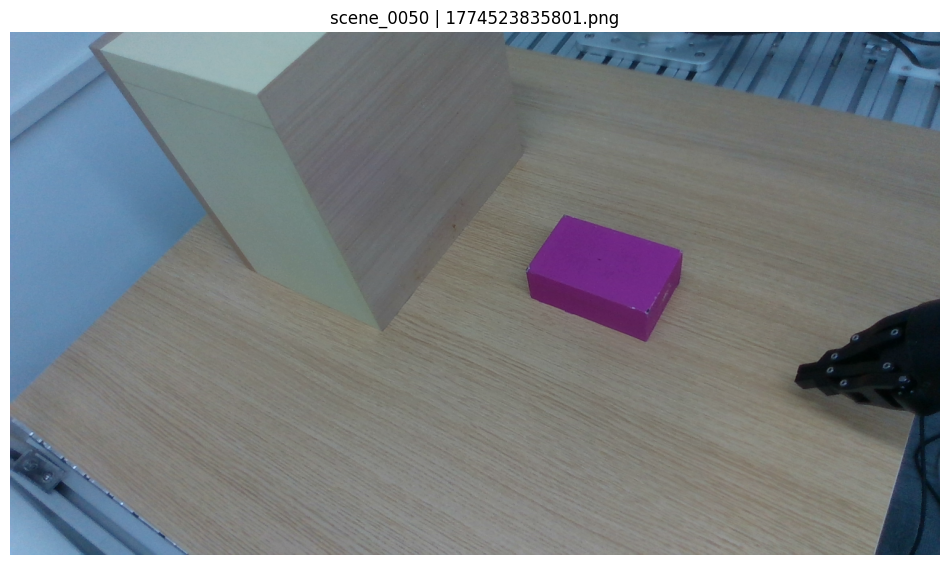

Reached the last scene.


In [3]:
def show_item(index, scene_name, image_path, error_msg=None):
    clear_output(wait=True)
    print(f'[{index + 1}/{len(items)}] {scene_name}')
    if error_msg is not None or image_path is None:
        print('error:', error_msg)
        return
    print(image_path)
    img = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.set_title(f'{scene_name} | {image_path.name}')
    ax.axis('off')
    plt.show()

for idx, (scene_name, image_path, error_msg) in enumerate(items):
    show_item(idx, scene_name, image_path, error_msg)
    if idx < len(items) - 1:
        input('Press Enter for next image...')
    else:
        print('Reached the last scene.')
